# Projection-TAGs gene-panel overlap

Six animals are arranged as three A/B pairs, with pair orientation chosen to balance sequencing platforms across panels. Every outer fold uses one complete pair for train, validation and test. Targets are filtered by the native W mask before fitting so every retained target is assayed in every animal.

In every same-budget arm, each cell sees exactly the resolved `K` genes from
panel A or B. At 100% overlap, both groups see the *same K genes*; they do
not suddenly see every source gene. The separately labeled all-`P`-gene
oracle is the only arm that exposes every original gene. Only input
expression is hidden; projection targets, target labels, measurement masks,
calibration rows and outer test cells are unchanged. Fold-specific scaling
reads only expression values visible in training. Missing values become zero
after centering, meaning the visible-training mean rather than biological zero.

Primary comparisons are mask-aware union PU, PU-MIRT and PU-Joint. Controls
include intersection-only PU, a one-fit disjoint-coefficient PU control,
the same-K 100% endpoint, and an all-gene PU oracle. Shared-A versus
Separate-A MIRT is enabled by default as a matched pooled-fit ablation:
its two arms differ only in whether the duplicated A/B gene blocks share
one target-loading matrix. Panel/eligible-animal target offsets live in
a separate nuisance design and use the same fixed stabilization in every
primary model. Two fully independent panel calibrations/fits are deliberately
not exposed here: they change both pooling and calibration and therefore do
not isolate target-loading sharing. RF is disabled and is never scheduled.

Run top to bottom in the OnDemand environment. Change `OVERLAP_GRID` in the
first code cell if needed. Compact diagnostics remain on by default; complete
tables are always written to CSV.


## Configuration


In [1]:
from pathlib import Path
import os

# Change this list before Run All. Realized overlap is also reported because
# odd panel sizes (for example BARseq K=11) require integer gene counts.
OVERLAP_GRID = [0.0, 0.25, 0.50, 0.75, 1.0]
PANEL_SIZE = None  # None uses floor(number_of_genes / 2).
INCLUDE_CONTROLS = True
INCLUDE_SHARED_A_ABLATION = True

# Fixed, model-identical stabilization for the separate panel/animal-by-target
# nuisance coefficients. It is not part of the hyperparameter search.
NUISANCE_L2 = 1e-4

N_OUTER_FOLDS = 3
N_REPETITIONS = 4
N_JOBS = 32
PARALLEL_UNIT = 'scenario'
STRATEGY = 'full_joint'
CANDIDATE_BUDGET = 32
SEED = 20260910
PAIRED_FRACTION = 0.20
POSITIVE_LOSS_RATES = (0.0,)
USE_LOCATION = False
USE_TARGET_FEATURES = False

# RF is intentionally excluded from this experiment for now.
RUN_RANDOM_FOREST = False
RUN_INFORMATION_CONTROLS = False
RUN_QIAO = False

SHOW_PROGRESS = True
PROGRESS_LEVEL = 'summary'
PROGRESS_INTERVAL_SECONDS = 60.0
SHOW_FULL_DIAGNOSTICS = False

BASE_DIR = Path(os.environ.get('GENE2WIRE_PROJECT_DIR', '/home/yueyue/gene2wire')).expanduser()
RAW_DATA_DIR = BASE_DIR / 'raw_data'
CHECKPOINT_DIR = BASE_DIR / 'checkpoints' / 'gene_overlap_v2'
EXPORT_DIR = BASE_DIR / 'paper_figure_exports'
FIGURE_DIR = BASE_DIR / 'figures' / 'gene_overlap_0910'
CODE_CACHE_DIR = BASE_DIR / 'code'

RESULTS_ONLY = False
EXISTING_EXPORT_DIRS = {'Projection-TAGs': None}  # Exact completed run directories or None.
EXPECTED_EXPORT_LABELS = ('Projection-TAGs',)
CORE_COMMIT = 'bd77d4103ff7aace7b16157c72b960953cf1a43b'
EXPECTED_SOURCE_HASH = '9ec276ca3560e004afeabf18e0d2dd9a665be0f61e86ab3e1df41bb02c75851a'
REPO_URL = 'https://github.com/Yue-stat/Gene2Wire.git'

for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[variable] = '1'

REQUIRED_MODULES = ['numpy', 'scipy', 'pandas', 'sklearn', 'joblib', 'threadpoolctl', 'matplotlib', 'yaml', 'IPython', 'rdata', 'openpyxl']
EXPECTED_PANEL_DESIGNS = {'Projection-TAGs': 'animal_aligned'}


## Load and verify the pinned Gene2Wire core


In [2]:
import hashlib
import importlib.util
import re
import shutil
import subprocess
import sys
import tempfile

if sys.version_info < (3, 10):
    raise RuntimeError('Select an OnDemand Python 3.10 or newer kernel.')
if not re.fullmatch(r'[0-9a-f]{40}', CORE_COMMIT):
    raise RuntimeError('This notebook needs its released 40-character CORE_COMMIT pin.')
if not re.fullmatch(r'[0-9a-f]{64}', EXPECTED_SOURCE_HASH):
    raise RuntimeError('This notebook needs its released source checksum.')

def notebook_source_hash(package_root):
    # Same byte-level convention as experiments.protocol.source_hash().
    digest = hashlib.sha256()
    for source_path in sorted(package_root.rglob('*.py')):
        digest.update(source_path.relative_to(package_root).as_posix().encode())
        digest.update(source_path.read_bytes())
    return digest.hexdigest()

def verify_checkout(checkout, require_git_pin=True):
    package_root = checkout / 'src' / 'gene2wire'
    if not package_root.is_dir():
        raise RuntimeError(f'Missing Gene2Wire sources in {checkout}')
    if require_git_pin:
        actual_commit = subprocess.check_output(
            ['git', '-C', str(checkout), 'rev-parse', 'HEAD'], text=True).strip()
        if actual_commit != CORE_COMMIT:
            raise RuntimeError(f'Cached code has commit {actual_commit}, expected {CORE_COMMIT}.')
    if notebook_source_hash(package_root) != EXPECTED_SOURCE_HASH:
        raise RuntimeError(f'Source checksum mismatch in {checkout}; use the released code.')
    return checkout

# Running from the exact local repository is supported without any network call.
CORE_CHECKOUT = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    package_root = candidate / 'src' / 'gene2wire'
    if package_root.is_dir() and notebook_source_hash(package_root) == EXPECTED_SOURCE_HASH:
        CORE_CHECKOUT = verify_checkout(candidate, require_git_pin=False)
        break

if CORE_CHECKOUT is None:
    CODE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cached_checkout = CODE_CACHE_DIR / CORE_COMMIT
    if not cached_checkout.exists():
        stage = Path(tempfile.mkdtemp(prefix='.gene2wire-download-', dir=CODE_CACHE_DIR))
        try:
            for arguments in (
                ['git', 'init', '--quiet', str(stage)],
                ['git', '-C', str(stage), 'remote', 'add', 'origin', REPO_URL],
                ['git', '-C', str(stage), 'fetch', '--quiet', '--depth', '1', 'origin', CORE_COMMIT],
                ['git', '-C', str(stage), 'checkout', '--quiet', '--detach', 'FETCH_HEAD'],
            ):
                subprocess.run(arguments, check=True)
            verify_checkout(stage)
            try:
                stage.rename(cached_checkout)
            except OSError:
                # Another notebook may have completed this same immutable cache.
                if not cached_checkout.exists():
                    raise
                verify_checkout(cached_checkout)
        finally:
            if stage.exists():
                shutil.rmtree(stage)
    CORE_CHECKOUT = verify_checkout(cached_checkout)

existing = sys.modules.get('gene2wire')
if existing is not None:
    same_path = Path(existing.__file__).resolve().parent == (CORE_CHECKOUT / 'src' / 'gene2wire').resolve()
    same_source = getattr(existing, '_notebook_source_hash_0908', None) == EXPECTED_SOURCE_HASH
    if not (same_path and same_source):
        raise RuntimeError('A different or unverified gene2wire is already imported. Restart the kernel, then Run All.')

missing = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Use an OnDemand Python kernel containing these dependencies: '
                       + ', '.join(missing) + '. See the repository environment instructions.')
sys.path.insert(0, str(CORE_CHECKOUT / 'src'))
import gene2wire
from gene2wire.experiments.protocol import Settings, source_hash
if source_hash() != EXPECTED_SOURCE_HASH:
    raise RuntimeError('Imported code does not match the released source checksum.')
gene2wire._notebook_source_hash_0908 = EXPECTED_SOURCE_HASH
for directory in (RAW_DATA_DIR, CHECKPOINT_DIR, EXPORT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print({'core_commit': CORE_COMMIT, 'source_hash': source_hash(),
       'imported_from': gene2wire.__file__, 'raw_cache': str(RAW_DATA_DIR),
       'checkpoints': str(CHECKPOINT_DIR), 'exports': str(EXPORT_DIR)})


{'core_commit': 'bd77d4103ff7aace7b16157c72b960953cf1a43b', 'source_hash': '9ec276ca3560e004afeabf18e0d2dd9a665be0f61e86ab3e1df41bb02c75851a', 'imported_from': '/home/yueyue/gene2wire/code/bd77d4103ff7aace7b16157c72b960953cf1a43b/src/gene2wire/__init__.py', 'raw_cache': '/home/yueyue/gene2wire/raw_data', 'checkpoints': '/home/yueyue/gene2wire/checkpoints/gene_overlap_v2', 'exports': '/home/yueyue/gene2wire/paper_figure_exports'}


## Shared model and overlap settings


In [3]:
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython.display import display
from gene2wire.experiments.protocol import Settings
from gene2wire.experiments.gene_overlap import (
    build_overlap_views, common_target_dataset, paired_group_folds,
    run_gene_overlap_experiment, validate_overlap_artifact,
)
from gene2wire.experiments.gene_overlap_plotting import plot_overlap_results
from gene2wire.experiments.reporting import (
    configure_full_display, configure_compact_display,
    load_existing_exports, display_diagnostics,
)

if SHOW_FULL_DIAGNOSTICS:
    configure_full_display()
else:
    configure_compact_display()

settings = Settings(
    n_outer_folds=N_OUTER_FOLDS, use_location=USE_LOCATION,
    use_target_features=USE_TARGET_FEATURES, n_jobs=N_JOBS,
    parallel_unit=PARALLEL_UNIT, n_repetitions=N_REPETITIONS,
    strategy=STRATEGY, candidate_budget=CANDIDATE_BUDGET, seed=SEED,
    paired_fraction=PAIRED_FRACTION, calibration_fractions=(PAIRED_FRACTION,),
    loss_rates=POSITIVE_LOSS_RATES,
    run_information_controls=RUN_INFORMATION_CONTROLS,
    run_random_forest=RUN_RANDOM_FOREST, run_qiao=RUN_QIAO,
    run_mechanism_controls=False, run_calibration_controls=False,
    nuisance_l2=NUISANCE_L2,
)
assert not RUN_RANDOM_FOREST and not settings.run_random_forest
assert not USE_LOCATION and not USE_TARGET_FEATURES
if SHOW_FULL_DIAGNOSTICS:
    display(pd.DataFrame([asdict(settings)]).T.rename(columns={0: 'settings'}))
else:
    print({'overlap_grid': OVERLAP_GRID, 'panel_size': PANEL_SIZE,
           'folds': N_OUTER_FOLDS, 'repetitions': N_REPETITIONS,
           'workers': N_JOBS, 'models': ['PU', 'PU-MIRT', 'PU-Joint'],
           'shared_A_ablation': INCLUDE_SHARED_A_ABLATION,
           'nuisance_l2': NUISANCE_L2,
           'random_forest': RUN_RANDOM_FOREST, 'positive_loss_rates': POSITIVE_LOSS_RATES})
if RESULTS_ONLY:
    all_artifacts = load_existing_exports(
        EXISTING_EXPORT_DIRS, expected_labels=EXPECTED_EXPORT_LABELS)
    for saved_label, saved_artifacts in all_artifacts.items():
        validate_overlap_artifact(
            saved_artifacts,
            expected_panel_design=EXPECTED_PANEL_DESIGNS[saved_label],
            expected_overlap_grid=OVERLAP_GRID,
            require_release_v2=True)
    print('RESULTS_ONLY: loading completed CSV/NPZ exports without raw-data loading or fitting.')


{'overlap_grid': [0.0, 0.25, 0.5, 0.75, 1.0], 'panel_size': None, 'folds': 3, 'repetitions': 4, 'workers': 32, 'models': ['PU', 'PU-MIRT', 'PU-Joint'], 'shared_A_ablation': True, 'nuisance_l2': 0.0001, 'random_forest': False, 'positive_loss_rates': (0.0,)}


## CPU allocation and active experiment workers


In [4]:
from gene2wire.experiments.workers import NotebookWorkerStatus

worker_status = None
if RESULTS_ONLY:
    print('RESULTS_ONLY: no training workers are launched.')
else:
    worker_status = NotebookWorkerStatus(requested_workers=N_JOBS)


## Outcome-independent design preview


In [5]:
def preview_overlap_views(label, views):
    first_rep = min(int(view.metadata['experiment_repetition']) for view in views)
    selected = [view for view in views
                if int(view.metadata['experiment_repetition']) == first_rep]
    rows = []
    for view in selected:
        context = view.metadata['experiment_context']
        arm = context['arm']
        panel_a = tuple(view.metadata['gene_overlap']['panel_A'])
        panel_b = tuple(view.metadata['gene_overlap']['panel_B'])
        source_gene_count = int(view.gene_matrix.shape[1])
        genes_per_cell = (source_gene_count if arm == 'all_gene_oracle'
                          else int(context['panel_size']))
        if arm == 'intersection':
            model_gene_columns = len(set(panel_a).intersection(panel_b))
        elif arm in {'disjoint_coefficient', 'shared_a', 'separate_a'}:
            model_gene_columns = 2 * int(context['panel_size'])
        elif arm == 'independent_panel':
            model_gene_columns = int(context['panel_size'])
        elif arm == 'all_gene_oracle':
            model_gene_columns = source_gene_count
        else:
            model_gene_columns = len(set(panel_a).union(panel_b))
        rows.append({
            'label': label, 'dataset': view.name,
            'design': context['panel_design'], 'arm': arm,
            'requested_overlap': context['requested_overlap'],
            'actual_overlap': context['actual_overlap'],
            'panel_size': context['panel_size'],
            'cells': len(view.cell_ids), 'targets': len(view.target_ids),
            'source_genes_P': source_gene_count,
            'available_genes_per_cell': genes_per_cell,
            'common_gene_count': len(set(panel_a).intersection(panel_b)),
            'union_gene_count': len(set(panel_a).union(panel_b)),
            'model_gene_columns': model_gene_columns,
            'panel_A_cells': int(np.sum(view.groups['overlap_panel'] == 'A')),
            'panel_B_cells': int(np.sum(view.groups['overlap_panel'] == 'B')),
            'models': ', '.join(view.metadata['model_allowlist']),
        })
    frame = pd.DataFrame(rows).drop_duplicates()
    display(frame)
    union = next(view for view in selected
                 if view.metadata['experiment_context']['arm'] == 'union')
    fold = union.split_builder(N_OUTER_FOLDS, SEED)[0]
    features = union.feature_builder(fold.train_rows, False, False)
    resolved_k = int(union.metadata['experiment_context']['panel_size'])
    source_p = int(union.gene_matrix.shape[1])
    print({
        'same_K_100pct_overlap': (
            f'both panels measure the same K={resolved_k} genes; this is not all {source_p} genes'),
        'all_P_gene_oracle': f'all P={source_p} genes are visible; plotted as a separate upper-bound point',
    })
    print({'first_fold_feature_shape': features.X.shape,
           'feature_blocks': dict(features.feature_blocks),
           'nuisance_shape': (None if features.X_nuisance is None
                              else features.X_nuisance.shape),
           'nuisance_names': tuple(features.nuisance_names),
           'targets_unchanged': True,
           'scaler_policy': 'visible outer-training expression only'})
    for checked_fold in union.split_builder(N_OUTER_FOLDS, SEED):
        for role, role_rows in (
                ('train', checked_fold.train_rows),
                ('validation', checked_fold.validation_rows),
                ('test', checked_fold.test_rows)):
            present = set(np.asarray(union.groups['overlap_panel'])[role_rows].astype(str))
            if present != {'A', 'B'}:
                raise ValueError(
                    f'Fold {checked_fold.outer_fold} {role} does not contain both gene panels')
    print('Fold audit: every train/validation/test role contains panels A and B.')
    if union.platform is not None and 'animal' in union.groups:
        animal_platform_panel = pd.DataFrame({
            'animal': np.asarray(union.groups['animal']).astype(str),
            'platform': np.asarray(union.platform).astype(str),
            'panel': np.asarray(union.groups['overlap_panel']).astype(str),
        }).drop_duplicates()
        if animal_platform_panel['animal'].duplicated().any():
            raise ValueError('Each Projection-TAGs animal must have one platform and one panel')
        platform_sets = animal_platform_panel.groupby('panel')['platform'].agg(lambda x: set(x))
        if len(platform_sets) != 2 or platform_sets.iloc[0] != platform_sets.iloc[1]:
            raise ValueError('Projection-TAGs panel assignment is confounded with platform')
        print('Animal-level platform × assigned gene-panel audit:')
        display(pd.crosstab(animal_platform_panel['panel'], animal_platform_panel['platform']))


In [6]:
def execute_views(label, views, export_name, run_settings=None):
    preview_overlap_views(label, views)
    return run_gene_overlap_experiment(
        views, settings if run_settings is None else run_settings,
        checkpoint_dir=CHECKPOINT_DIR, export_dir=EXPORT_DIR,
        export_name=export_name, progress=SHOW_PROGRESS,
        progress_interval=PROGRESS_INTERVAL_SECONDS,
        progress_level=PROGRESS_LEVEL, worker_status=worker_status)


## Load Projection-TAGs and audit common target coverage


In [7]:
LOCATION_FEATURES_CSV = None
TARGET_FEATURES_CSV = None


In [8]:
if not RESULTS_ONLY:
    from gene2wire.experiments.datasets.projection_tags import load_projection_tags
    dataset = load_projection_tags(
        RAW_DATA_DIR / 'Projection_TAGs',
        location_features_csv=LOCATION_FEATURES_CSV,
        target_features_csv=TARGET_FEATURES_CSV)
    dataset = common_target_dataset(dataset, 'animal')
    if not np.asarray(dataset.measured, dtype=bool).all():
        raise ValueError('Common-target Projection-TAGs W audit did not retain full coverage')
    pairs = ((1, 4), (2, 6), (3, 5))
    dataset = paired_group_folds(dataset, 'animal', pairs)
    # Preserve one A/B animal in each pair while balancing the two
    # sequencing platforms across panels (two RNA + one multiome each).
    mapping = {1: 'A', 4: 'B', 2: 'B', 6: 'A', 3: 'A', 5: 'B'}
    views = build_overlap_views(
        dataset, OVERLAP_GRID, panel_size=PANEL_SIZE,
        n_repetitions=N_REPETITIONS, panel_design='animal_aligned',
        aligned_group='animal', aligned_mapping=mapping,
        include_controls=INCLUDE_CONTROLS,
        include_shared_a_ablation=INCLUDE_SHARED_A_ABLATION,
        seed=SEED)
    display(pd.DataFrame([dataset.metadata['common_target_audit']]))


,group,source_target_count,retained_target_count,retained_targets
0,animal,7,6,"[MOp, VP, PAG, MY, SCL, SCS]"


## Run paired-animal gene-overlap experiment


In [9]:
if not RESULTS_ONLY:
    all_artifacts = {'Projection-TAGs': execute_views(
        'Projection-TAGs', views, 'Projection_TAGs_gene_overlap_0910')}


,label,dataset,design,arm,requested_overlap,actual_overlap,panel_size,cells,targets,source_genes_P,available_genes_per_cell,common_gene_count,union_gene_count,model_gene_columns,panel_A_cells,panel_B_cells,models
0,Projection-TAGs,Projection-TAGs,animal_aligned,union,0.00,0.00,16,37827,6,32,16,0,32,32,20186,17641,"PU, PU-MIRT, PU-Joint"
1,Projection-TAGs,Projection-TAGs,animal_aligned,intersection,0.00,0.00,16,37827,6,32,16,0,32,0,20186,17641,PU
2,Projection-TAGs,Projection-TAGs,animal_aligned,disjoint_coefficient,0.00,0.00,16,37827,6,32,16,0,32,32,20186,17641,PU
3,Projection-TAGs,Projection-TAGs,animal_aligned,shared_a,0.00,0.00,16,37827,6,32,16,0,32,32,20186,17641,PU-MIRT
4,Projection-TAGs,Projection-TAGs,animal_aligned,separate_a,0.00,0.00,16,37827,6,32,16,0,32,32,20186,17641,PU-MIRT
5,Projection-TAGs,Projection-TAGs,animal_aligned,union,0.25,0.25,16,37827,6,32,16,4,28,28,20186,17641,"PU, PU-MIRT, PU-Joint"
6,Projection-TAGs,Projection-TAGs,animal_aligned,intersection,0.25,0.25,16,37827,6,32,16,4,28,4,20186,17641,PU
7,Projection-TAGs,Projection-TAGs,animal_aligned,disjoint_coefficient,0.25,0.25,16,37827,6,32,16,4,28,32,20186,17641,PU
8,Projection-TAGs,Projection-TAGs,animal_aligned,shared_a,0.25,0.25,16,37827,6,32,16,4,28,32,20186,17641,PU-MIRT
9,Projection-TAGs,Projection-TAGs,animal_aligned,separate_a,0.25,0.25,16,37827,6,32,16,4,28,32,20186,17641,PU-MIRT


{'same_K_100pct_overlap': 'both panels measure the same K=16 genes; this is not all 32 genes', 'all_P_gene_oracle': 'all P=32 genes are visible; plotted as a separate upper-bound point'}
{'first_fold_feature_shape': (37827, 32), 'feature_blocks': {'gene_union': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31)}, 'nuisance_shape': (37827, 1), 'nuisance_names': ('overlap_panel[B]',), 'targets_unchanged': True, 'scaler_policy': 'visible outer-training expression only'}
Fold audit: every train/validation/test role contains panels A and B.
Animal-level platform × assigned gene-panel audit:


platform,10X RNA,10X multiome
panel,,
A,1,2
B,1,2


[cache] verified result summaries 0/432; remaining 432 require cache checks or processing. Model/candidate/refit reuse is counted during execution; unchecked does not mean uncached.
[running 1min] finished units 65/432, current time 2026-09-10 21:26:39 PDT; restored results 0, reused fits 0, new/mixed 65
[running 2min] finished units 130/432, current time 2026-09-10 21:27:39 PDT; restored results 0, reused fits 0, new/mixed 130
[running 3min] finished units 163/432, current time 2026-09-10 21:28:39 PDT; restored results 0, reused fits 0, new/mixed 163
[running 4min] finished units 189/432, current time 2026-09-10 21:29:39 PDT; restored results 0, reused fits 0, new/mixed 189
[running 5min] finished units 223/432, current time 2026-09-10 21:30:39 PDT; restored results 0, reused fits 0, new/mixed 223
[running 6min] finished units 254/432, current time 2026-09-10 21:31:40 PDT; restored results 0, reused fits 0, new/mixed 254
[running 7min] finished units 288/432, current time 2026-09-10 2

## Figures, essential metrics, selected hyperparameters and diagnostics


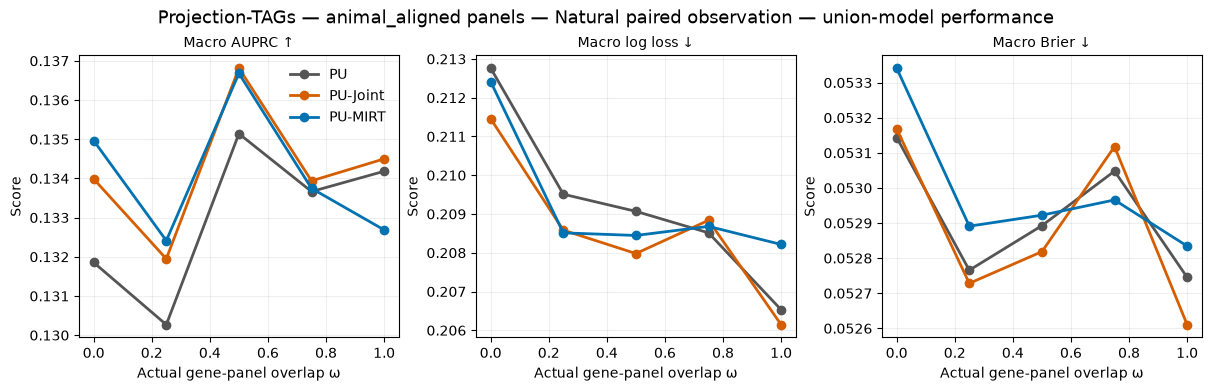

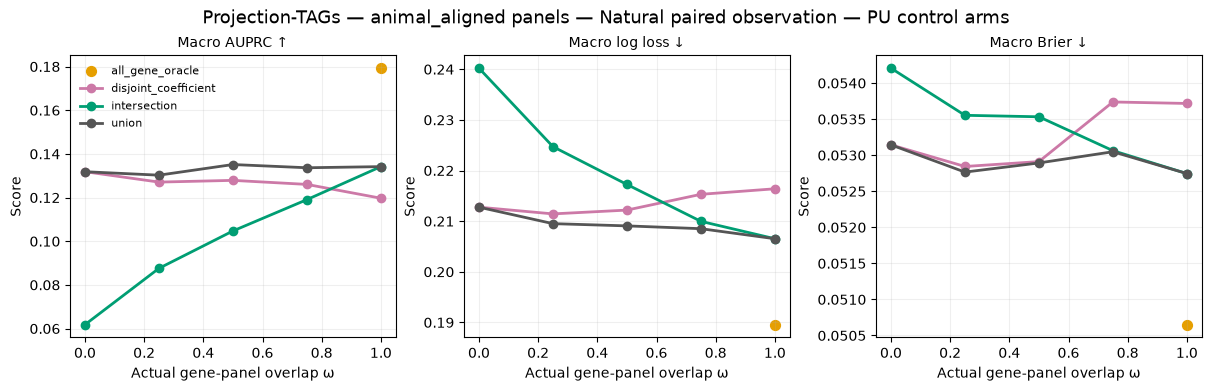

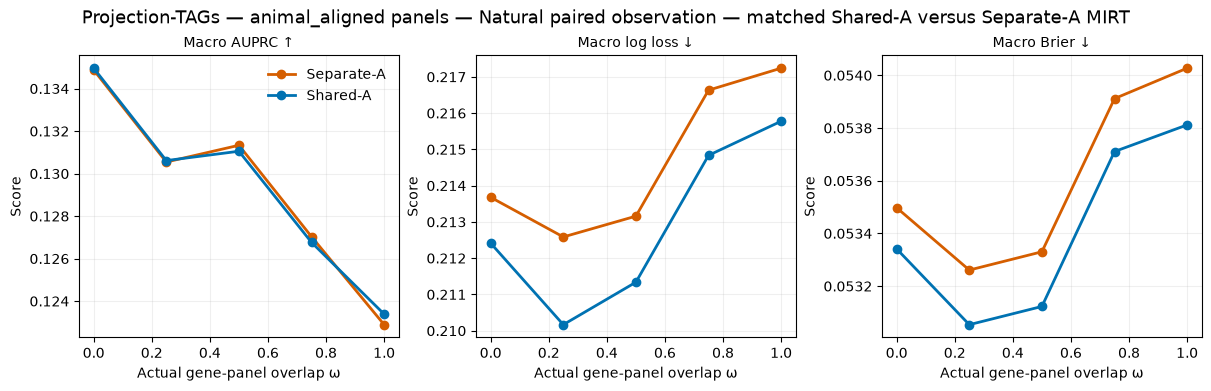

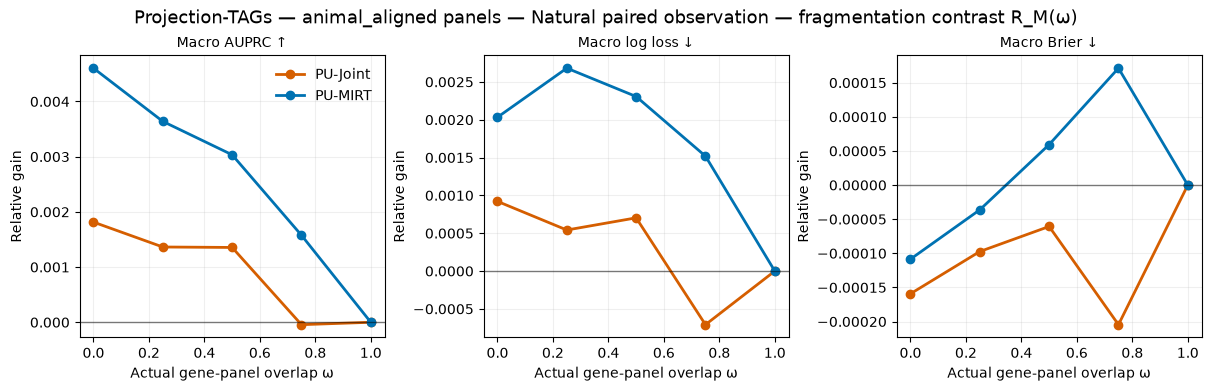

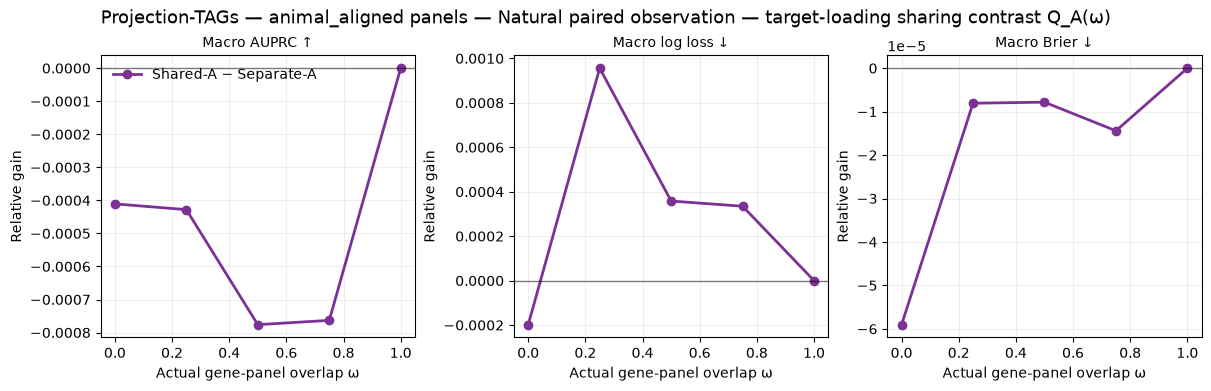


Projection-TAGs — concise diagnostics
All result tables, predictions and settings: /home/yueyue/gene2wire/paper_figure_exports/Projection_TAGs_gene_overlap_0910/b682eb634d2b5bade960
Saved run settings (authoritative for these results): {'n_outer_folds': 3, 'n_repetitions': 4, 'use_location': False, 'use_target_features': False, 'paired_fraction': 0.2, 'strategy': 'full_joint', 'candidate_budget': 32}
Execution settings recorded in this export: {'parallel_unit': 'scenario', 'requested_n_jobs': 32, 'effective_n_jobs': 32, 'scheduled_tasks': 312, 'planned_model_evaluations': 432, 'cached_model_evaluations': 0, 'reused_fit_model_evaluations': 0, 'new_or_mixed_model_evaluations': 432, 'unknown_fit_model_evaluations': 0}
Metric means give folds equal weight within each repetition, then repetitions equal weight. Endpoints use each model's largest recorded primary loss (or natural paired labels); block experiments use the largest block fraction and masked training. PU curves retain all primar

,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h,macro_hidden_recall_at_h,macro_predicted_prevalence,macro_reference_prevalence,worst_panel_macro_auprc,worst_panel_macro_log_loss,worst_panel_macro_brier
0,all_gene_oracle,1.00,1.00,PU,0.179277,0.189558,0.050650,0.101606,0.101606,0.042548,0.054022,0.097753,0.255719,0.069783
1,disjoint_coefficient,0.00,0.00,PU,0.131855,0.212762,0.053144,0.070416,0.070416,0.045431,0.054022,0.075367,0.274670,0.070796
2,disjoint_coefficient,0.25,0.25,PU,0.127098,0.211436,0.052844,0.070491,0.070491,0.045948,0.054022,0.075660,0.271692,0.070160
3,disjoint_coefficient,0.50,0.50,PU,0.127889,0.212186,0.052911,0.069156,0.069156,0.045205,0.054022,0.076260,0.272372,0.070153
4,disjoint_coefficient,0.75,0.75,PU,0.126041,0.215302,0.053738,0.066638,0.066638,0.045247,0.054022,0.076089,0.277115,0.071221
5,disjoint_coefficient,1.00,1.00,PU,0.119709,0.216394,0.053718,0.064829,0.064829,0.046002,0.054022,0.073148,0.277172,0.070986
6,intersection,0.00,0.00,PU,0.061800,0.240216,0.054207,0.023953,0.023953,0.047064,0.054022,0.036340,0.286198,0.068519
7,intersection,0.25,0.25,PU,0.087601,0.224713,0.053553,0.044496,0.044496,0.046788,0.054022,0.054174,0.276710,0.068980
8,intersection,0.50,0.50,PU,0.104715,0.217250,0.053533,0.054254,0.054254,0.046387,0.054022,0.066884,0.270464,0.069126
9,intersection,0.75,0.75,PU,0.119068,0.209966,0.053063,0.063257,0.063257,0.045963,0.054022,0.070524,0.267301,0.069813



pu_curves: showing 36/36 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=16; probability_semantics=reference


,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h
0,all_gene_oracle,1.00,1.00,PU,0.179277,0.189558,0.050650,0.101606
1,disjoint_coefficient,0.00,0.00,PU,0.131855,0.212762,0.053144,0.070416
2,disjoint_coefficient,0.25,0.25,PU,0.127098,0.211436,0.052844,0.070491
3,disjoint_coefficient,0.50,0.50,PU,0.127889,0.212186,0.052911,0.069156
4,disjoint_coefficient,0.75,0.75,PU,0.126041,0.215302,0.053738,0.066638
5,disjoint_coefficient,1.00,1.00,PU,0.119709,0.216394,0.053718,0.064829
6,intersection,0.00,0.00,PU,0.061800,0.240216,0.054207,0.023953
7,intersection,0.25,0.25,PU,0.087601,0.224713,0.053553,0.044496
8,intersection,0.50,0.50,PU,0.104715,0.217250,0.053533,0.054254
9,intersection,0.75,0.75,PU,0.119068,0.209966,0.053063,0.063257



selected_hyperparameters_by_repetition: showing 60/144 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=16
Bounded, context-balanced preview: 84 rows omitted; 1/1 contexts shown. Use the complete CSV exports for all configurations/contexts.


...


overlap_contrasts: showing 30/30 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=16


,actual_overlap,model,metric,mean_advantage_vs_PU,mean_R_vs_100pct,sd_R_vs_100pct,n_repetitions
0,0.00,PU-Joint,macro_auprc,0.002131,0.001815,0.002997,4
1,0.00,PU-Joint,macro_brier,-0.000024,-0.000159,0.000333,4
2,0.00,PU-Joint,macro_log_loss,0.001306,0.000921,0.000769,4
3,0.00,PU-MIRT,macro_auprc,0.003108,0.004604,0.002785,4
4,0.00,PU-MIRT,macro_brier,-0.000198,-0.000109,0.000321,4
5,0.00,PU-MIRT,macro_log_loss,0.000348,0.002033,0.001177,4
6,0.25,PU-Joint,macro_auprc,0.001680,0.001364,0.002486,4
7,0.25,PU-Joint,macro_brier,0.000037,-0.000097,0.000130,4
8,0.25,PU-Joint,macro_log_loss,0.000927,0.000542,0.001203,4
9,0.25,PU-MIRT,macro_auprc,0.002143,0.003640,0.002314,4


Recorded failed units: 0.
All scenarios, final-fit records: 432; not converged: 0; status not recorded: 0.
All scenarios, candidate records: 7392; not converged: 0; status not recorded: 0.
Compact output is capped at 8 tables / 300 rows / 14 columns. Set SHOW_FULL_DIAGNOSTICS=True to display every saved table and the full manifest.


{'Projection-TAGs': [PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/Projection-TAGs/Projection-TAGs_animal_aligned_natural_primary.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/Projection-TAGs/Projection-TAGs_animal_aligned_natural_controls.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/Projection-TAGs/Projection-TAGs_animal_aligned_natural_shared_A_ablation.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/Projection-TAGs/Projection-TAGs_animal_aligned_natural_fragmentation_contrast.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/Projection-TAGs/Projection-TAGs_animal_aligned_natural_shared_A_contrast.pdf')]}

CSV/NPZ exports: {'Projection-TAGs': '/home/yueyue/gene2wire/paper_figure_exports/Projection_TAGs_gene_overlap_0910/b682eb634d2b5bade960'}
Persistent checkpoints: /home/yueyue/gene2wire/checkpoints/gene_overlap_v2


In [10]:
figure_paths = {}
for label, artifacts in all_artifacts.items():
    paths = plot_overlap_results(
        artifacts, FIGURE_DIR / label.replace(' ', '_'),
        prefix=label.replace(' ', '_'), display=True)
    if not paths:
        raise RuntimeError(f'No gene-overlap figures were produced for {label!r}')
    figure_paths[label] = paths
    display_diagnostics(artifacts, label=label, full=SHOW_FULL_DIAGNOSTICS)
display(figure_paths)
print('CSV/NPZ exports:', {label: str(value.export_dir) for label, value in all_artifacts.items()})
print('Persistent checkpoints:', CHECKPOINT_DIR)
